In [40]:
%pip install selenium

                                              0.0/9.6 MB ? eta -:--:--
                                              0.1/9.6 MB 3.6 MB/s eta 0:00:03
     -                                        0.4/9.6 MB 4.9 MB/s eta 0:00:02
     ----                                     1.1/9.6 MB 8.4 MB/s eta 0:00:02
     ---------                                2.3/9.6 MB 13.2 MB/s eta 0:00:01
     ---------------                          3.6/9.6 MB 16.4 MB/s eta 0:00:01
     --------------------                     4.9/9.6 MB 18.5 MB/s eta 0:00:01
     --------------------------               6.3/9.6 MB 20.1 MB/s eta 0:00:01
     -------------------------------          7.5/9.6 MB 20.9 MB/s eta 0:00:01
     ------------------------------------     8.7/9.6 MB 21.5 MB/s eta 0:00:01
     ---------------------------------------  9.6/9.6 MB 21.9 MB/s eta 0:00:01
     ---------------------------------------- 9.6/9.6 MB 20.4 MB/s eta 0:00:00
                                              0.0/135.7 kB ? et

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
requests 2.29.0 requires urllib3<1.27,>=1.21.1, but you have urllib3 2.6.3 which is incompatible.


In [48]:
# Note: do NOT run "pip install ..." as plain Python — that caused the SyntaxError.
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma, norm, fisk, wilcoxon
from sklearn.cluster import KMeans
import re
import sys
import time
import pickle
import requests
from pathlib import Path
import logging
from glob import glob

# Selenium optional import — fail gracefully if not installed in the environment
try:
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.common.by import By
    from selenium.webdriver.support.ui import Select, WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
except ImportError:
    webdriver = None
    Options = None

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [53]:
# Configuration
config = {
    'input_data_bow': project_root / 'data' / 'input_data' / 'for_report'/'bow' ,
    'input_data_oldman': project_root / 'data' / 'input_data' / 'for_report' / 'oldman',
    'gap_filled_bow_canswe_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' /'bow_swe_gapfilled_data_final.nc',
    'gap_filled_oldman_canswe_data' : project_root / 'data' / 'output_data' / 'for_report'/'oldman' /'oldman_swe_gapfilled_data_final.nc',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'output_plots': project_root / 'data' / 'output_plots' / 'for_report',
    'output_path': project_root / 'data' / 'output_data' / 'for_report',}

In [ ]:
download_folder = Path(project_root / 'data' / 'input_data' / 'for_report'/'bow'/'downloaded_data')
download_folder.mkdir(parents=True, exist_ok=True)

stations = [
    "SUNSHINE VILLAGE",
    "THREE ISLE LAKE",
    "LITTLE ELBOW SUMMIT",
    "LOST CREEK SOUTH",
    "MOUNT ODLUM III",
    "SKOKI LODGE"
]

data_source = "Snow Water Equivalent (C.Corrected-Sensor)"

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": str(download_folder),
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

driver.get("https://rivers.alberta.ca/Download")
time.sleep(5)

for i, select in enumerate(driver.find_elements(By.TAG_NAME, "select")):
    print("\n--- SELECT", i, "---")
    print("id:", select.get_attribute("id"))
    print("name:", select.get_attribute("name"))
    for option in select.find_elements(By.TAG_NAME, "option"):
        print(option.text)

# Accept download disclaimer if it appears
try:
    accept_btn = wait.until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(., 'Accept')]"))
    )
    accept_btn.click()
except:
    pass

for station in stations:
    print(f"Downloading {station}...")

    # Select station dropdown
    station_dropdown = wait.until(
        EC.presence_of_element_located((By.XPATH, "//select[contains(@id, 'station') or contains(@name, 'station')]"))
    )
    Select(station_dropdown).select_by_visible_text(station)

    time.sleep(2)

    # Select data source dropdown
    source_dropdown = wait.until(
        EC.presence_of_element_located((By.XPATH, "//select[contains(@id, 'data') or contains(@name, 'data') or contains(@id, 'source')]"))
    )
    Select(source_dropdown).select_by_visible_text(data_source)

    time.sleep(1)

    # Click download button
    download_btn = wait.until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(., 'Download') or contains(., 'download')]"))
    )
    download_btn.click()

    time.sleep(5)

print("Finished downloading.")
driver.quit()


--- SELECT 0 ---
id: searchStationInputResults
name: 

--- SELECT 1 ---
id: searchAddressInputSel
name: 


--- SELECT 2 ---
id: searchAddressInputResults
name: 

--- SELECT 3 ---
id: latitudeCardinal
name: zoomToLatitudeCardinal



--- SELECT 4 ---
id: longitudeCardinal
name: zoomTooLongitudeCardinal



--- SELECT 5 ---
id: zone
name: zone



--- SELECT 6 ---
id: searchMeridianInput
name: searchMeridianInput




--- SELECT 7 ---
id: cmd-baseMapSwitcher-esri-basemaps
name: 







--- SELECT 8 ---
id: compareYearSelect
name: 







TimeoutException: Message: 
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff60fbba8e5+14e45]
	chromedriver!GetHandleVerifier [0x7ff60fbba950+14eb0]
	chromedriver!(No symbol) [0x7ff60f92d6ed]
	chromedriver!(No symbol) [0x7ff60f986cfe]
	chromedriver!(No symbol) [0x7ff60f98700c]
	chromedriver!(No symbol) [0x7ff60f9d7cb7]
	chromedriver!(No symbol) [0x7ff60f9d483b]
	chromedriver!(No symbol) [0x7ff60f9790e8]
	chromedriver!(No symbol) [0x7ff60f979fc3]
	chromedriver!GetHandleVerifier [0x7ff60fed0149+32a6a9]
	chromedriver!GetHandleVerifier [0x7ff60feca715+324c75]
	chromedriver!GetHandleVerifier [0x7ff60feec012+346572]
	chromedriver!GetHandleVerifier [0x7ff60fbd7cb5+32215]
	chromedriver!GetHandleVerifier [0x7ff60fbe087c+3addc]
	chromedriver!GetHandleVerifier [0x7ff60fbc40e4+1e644]
	chromedriver!GetHandleVerifier [0x7ff60fbc4296+1e7f6]
	chromedriver!GetHandleVerifier [0x7ff60fba8737+2c97]
	KERNEL32!BaseThreadInitThunk [0x7ff93d937374+14]
	ntdll!RtlUserThreadStart [0x7ff93db1cc91+21]


In [52]:
stations = {
    "SUNSHINE VILLAGE": "05BB803",      
    "THREE ISLE LAKE": "05BF824",
    "LITTLE ELBOW": "05BG825",
    "LOST CREEK": "05BH826",
    "MOUNT ODLUM III": "05BI827",
    "SKOKI LODGE": "05CA805"
}

# --- output folder ---
out_dir = Path(project_root / 'data' / 'input_data' / 'for_report'/'bow'/'downloaded_data')
out_dir.mkdir(parents=True, exist_ok=True)

# --- API endpoint ---
url = "https://rivers.alberta.ca/DataService/DownloadCsv"

# --- download loop ---
for name, station_id in stations.items():
    params = {
        "stationId": station_id,
        "data source": "Snow Water Equivalent (C.Corrected-Sensor)",     
        "format": "csv"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        file_path = out_dir / f"{name.replace(' ', '_')}.csv"
        with open(file_path, "wb") as f:
            f.write(response.content)

        print(f"Downloaded: {name}")
    else:
        print(f"Failed: {name}")

Failed: SUNSHINE VILLAGE
Failed: THREE ISLE LAKE
Failed: LITTLE ELBOW
Failed: LOST CREEK
Failed: MOUNT ODLUM III
Failed: SKOKI LODGE


# Data preparation

1. Create historic SWE dataset (Gap-filled CANSWE data for each basin).  

In [54]:
# open canswe data
bow_canswe_gapfilled_ds = xr.open_dataset(config['gap_filled_bow_canswe_data'])

oldman_canswe_gapfilled_ds = xr.open_dataset(config['gap_filled_oldman_canswe_data'])

# convert to dataframe and display
bow_canswe_gapfilled_df = bow_canswe_gapfilled_ds.to_dataframe()
bow_canswe_gapfilled_df.reset_index(inplace=True)
display(bow_canswe_gapfilled_df.head())

oldman_canswe_gapfilled_df = oldman_canswe_gapfilled_ds.to_dataframe()
oldman_canswe_gapfilled_df.reset_index(inplace=True)    
display(oldman_canswe_gapfilled_df.head())

,time,station_id,lat,lon,station_name,SWE
0,1980-01-01,ALE-05BA801,51.423084,-116.183693,BOW RIVER,NaN
1,1980-01-01,ALE-05BA802,51.437962,-116.181274,PIPESTONE UPPER,NaN
2,1980-01-01,ALE-05BA806,51.416618,-116.238274,MIRROR LAKE,NaN
3,1980-01-01,ALE-05BA808,51.424427,-116.213310,CHATEAU LAWN,NaN
4,1980-01-01,ALE-05BA810,51.474091,-116.102745,PTARMIGAN HUT,NaN


,time,station_id,lat,lon,station_name,SWE
0,1980-01-01,ALE-05AA801,49.279552,-114.372910,WEST CASTLE BUSH,NaN
1,1980-01-01,ALE-05AA803,49.745266,-114.612213,ALLISON PASS,NaN
2,1980-01-01,ALE-05AA805,49.266666,-114.349998,WEST CASTLE SNOW,NaN
3,1980-01-01,ALE-05AA806,49.816666,-114.633331,RACE HORSE CREEK,NaN
4,1980-01-01,ALE-05AA809,49.359940,-114.518234,GARDINER H.W.,NaN


2. Get latest data for the season from the downloaded data 

In [57]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    05BB803_SW_C.Corrected-Seasonal.csv
    """
    fname = Path(filepath).name
    m = re.search(r'([0-9A-Za-z]+)_', fname)
    return m.group(1) if m else fname


def find_data_start(filepath):
    """
    Find the row number right after the '#Timestamp;Value' line.
    """
    with open(filepath, 'r', encoding='utf-8-sig', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('#Timestamp;Value'):
                return i + 1
    raise ValueError(f"Could not find '#Timestamp;Value' header in {filepath}")


def read_alberta_timeseries(filepath, value_name='SWE'):
    """
    Read one Alberta seasonal CSV file.

    Returns columns:
    station_id, time, SWE
    """
    station_id = extract_station_id(filepath)
    skiprows = find_data_start(filepath)

    df = pd.read_csv(
        filepath,
        sep=';',
        skiprows=skiprows,
        names=['Timestamp', 'Value'],
        encoding='utf-8-sig'
    )

    df['time'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df[value_name] = pd.to_numeric(df['Value'], errors='coerce')

    df = df.dropna(subset=['time']).copy()
    df['station_id'] = station_id

    return df[['station_id', 'time', value_name]]


def add_season_year_nov_may(df, time_col='time'):
    """
    Keep only Nov-May data and assign season_year.

    Example:
    Nov-Dec 1984 -> season_year 1984
    Jan-May 1985 -> season_year 1984
    """
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out = out.dropna(subset=[time_col]).copy()
    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    # Keep only Nov-May
    out = out[out['month'].isin([10,11, 12, 1, 2, 3, 4, 5])].copy()

    out['season_year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'season_year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    out = out.drop(columns=['month', 'year'])

    return out


def read_all_alberta_csvs(folderpath, value_name='SWE'):
    """
    Read all CSV files in a folder and combine them.

    Returns columns:
    station_id, time, SWE
    """
    folder = Path(folderpath)
    csv_files = sorted(folder.glob('*.csv'))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    all_dfs = []
    for file in csv_files:
        try:
            df = read_alberta_timeseries(file, value_name=value_name)
            all_dfs.append(df)
            print(f"Read: {file.name} -> {len(df)} rows")
        except Exception as e:
            print(f"Skipped {file.name}: {e}")

    if not all_dfs:
        raise ValueError("No valid CSV files were read.")

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined.sort_values(['station_id', 'time']).reset_index(drop=True)

    return combined


def build_swe_table(folderpath):
    """
    Full pipeline:
    1. Read all CSVs in folder
    2. Add season_year
    3. Return final table with columns:
       station_id, time, SWE, season_year
    """
    df = read_all_alberta_csvs(folderpath, value_name='SWE')
    df = add_season_year_nov_may(df, time_col='time')

    df = df[['station_id', 'time', 'SWE', 'season_year']].copy()
    df = df.sort_values(['station_id', 'time']).reset_index(drop=True)

    return df

def daily_aggregate(df, value_col='SWE', how='last'):
    """
    Aggregate to daily data by station.
    For SWE, 'last' is usually the best choice.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")


In [58]:
# Open CSVs, keep last SWE value per day, and create daily tables

# Bow basin
bow_raw = build_swe_table(config['input_data_bow'])
bow_swe_table = (
    bow_raw.sort_values(['station_id', 'season_year', 'time'])
           .set_index('time')
           .groupby(['station_id', 'season_year'])['SWE']
           .resample('D')
           .last()
           .reset_index()
)

# Oldman basin
oldman_raw = build_swe_table(config['input_data_oldman'])
oldman_swe_table = (
    oldman_raw.sort_values(['station_id', 'season_year', 'time'])
              .set_index('time')
              .groupby(['station_id', 'season_year'])['SWE']
              .resample('D')
              .last()
              .reset_index()
)

# keep only 2024 and 2025 season year
#years = [2024, 2025]

#bow_swe_table = bow_swe_table[bow_swe_table['season_year'].isin(years)].copy()
#oldman_swe_table = oldman_swe_table[oldman_swe_table['season_year'].isin(years)].copy()

display(bow_raw.head())
display(oldman_raw.head())
display(bow_swe_table.head())
display(oldman_swe_table.head())
#display(daily_table.head())

Read: 05BB803_SW_C.Corrected-Seasonal.csv -> 356617 rows
Read: 05BF824_SW_C.Corrected-Seasonal.csv -> 340987 rows
Read: 05BJ805_SW_C.Corrected-Seasonal.csv -> 325320 rows
Read: 05BL811_SW_C.Corrected-Seasonal.csv -> 283050 rows
Read: 05BL812_SW_C.Corrected-Seasonal.csv -> 333802 rows
Read: 05CA805_SW_C.Corrected-Seasonal.csv -> 252661 rows
Read: 05AA809_SW_C.Corrected-Seasonal.csv -> 290591 rows
Read: 05AA817_SW_C.Corrected-Seasonal.csv -> 255260 rows
Read: 05AD803_SW_C.Corrected-Seasonal.csv -> 62356 rows


,station_id,time,SWE,season_year
0,05BB803,1984-03-12 10:00:00,472.0,1983
1,05BB803,1984-03-12 11:00:00,472.0,1983
2,05BB803,1984-03-12 12:00:00,472.0,1983
3,05BB803,1984-03-12 13:00:00,472.0,1983
4,05BB803,1984-03-12 14:00:00,472.0,1983


,station_id,time,SWE,season_year
0,05AA809,1984-04-01 00:00:00,427.0,1983
1,05AA809,1984-04-01 01:00:00,427.0,1983
2,05AA809,1984-04-01 02:00:00,428.0,1983
3,05AA809,1984-04-01 03:00:00,428.0,1983
4,05AA809,1984-04-01 04:00:00,428.0,1983


,station_id,season_year,time,SWE
0,05BB803,1983,1984-03-12,473.0
1,05BB803,1983,1984-03-13,485.0
2,05BB803,1983,1984-03-14,492.0
3,05BB803,1983,1984-03-15,492.0
4,05BB803,1983,1984-03-16,492.0


,station_id,season_year,time,SWE
0,05AA809,1983,1984-04-01,428.0
1,05AA809,1983,1984-04-02,429.0
2,05AA809,1983,1984-04-03,429.0
3,05AA809,1983,1984-04-04,430.0
4,05AA809,1983,1984-04-05,443.0


3. Extract monitoring stations historic data 

In [59]:
def extract_historic_by_station_ids(
    historic_df,
    current_df,
    historic_id_col="station_id",
    current_id_col="station_id",
):
    """
    Extract historic rows for stations present in current_df.
    Handles exact matches and prefixed historic IDs (e.g., ALE-05BB803 -> 05BB803).
    """
    target_ids = current_df[current_id_col].dropna().astype(str).unique().tolist()
    target_set = set(target_ids)

    historic_unique_ids = historic_df[historic_id_col].dropna().astype(str).unique().tolist()

    # Map historic station IDs to current station IDs
    id_map = {}
    for hid in historic_unique_ids:
        if hid in target_set:
            id_map[hid] = hid
            continue

        matches = [tid for tid in target_ids if hid.endswith(tid)]
        if len(matches) == 1:
            id_map[hid] = matches[0]

    # Filter and add matched station id
    out = historic_df[historic_df[historic_id_col].astype(str).isin(id_map.keys())].copy()
    out["source_station_id"] = out[historic_id_col].astype(str)
    out[current_id_col] = out["source_station_id"].map(id_map)

    out = out.sort_values([current_id_col, "time"]).reset_index(drop=True)
    return out


# Extract historic data corresponding to station IDs in latest-season tables
bow_historic_matched = extract_historic_by_station_ids(
    historic_df=bow_canswe_gapfilled_df,
    current_df=bow_swe_table,
)

# add season_year to historic matched data
bow_historic_matched = add_season_year_nov_may(bow_historic_matched, time_col='time')
#drop 1979 season year from historic matched data
bow_historic_matched = bow_historic_matched[bow_historic_matched['season_year'] != 1979].copy()

oldman_historic_matched = extract_historic_by_station_ids(
    historic_df=oldman_canswe_gapfilled_df,
    current_df=oldman_swe_table,
)
oldman_historic_matched = add_season_year_nov_may(oldman_historic_matched, time_col='time')
#drop 1979 season year from historic matched data
oldman_historic_matched = oldman_historic_matched[oldman_historic_matched['season_year'] != 1979].copy()


display(bow_historic_matched.head())
display(oldman_historic_matched.head())
print("Bow rows:", len(bow_historic_matched))
print("Oldman rows:", len(oldman_historic_matched))

,time,station_id,lat,lon,station_name,SWE,source_station_id,season_year
274,1980-10-01,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
275,1980-10-02,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
276,1980-10-03,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
277,1980-10-04,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
278,1980-10-05,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980


,time,station_id,lat,lon,station_name,SWE,source_station_id,season_year
274,1980-10-01,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
275,1980-10-02,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
276,1980-10-03,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
277,1980-10-04,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
278,1980-10-05,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980


Bow rows: 64218
Oldman rows: 32109


4. Add station name column to real-time data

In [60]:
# Bow River Basin
bow_station_lookup = bow_historic_matched.drop_duplicates('station_id').set_index('station_id')['station_name']

bow_swe_table['station_name'] = bow_swe_table['station_id'].map(bow_station_lookup)

#bow_swe_table = bow_swe_table.drop(columns=['source_station_id', 'lat', 'lon'])

display(bow_swe_table)

,station_id,season_year,time,SWE,station_name
0,05BB803,1983,1984-03-12,473.000,SUNSHINE VILLAGE
1,05BB803,1983,1984-03-13,485.000,SUNSHINE VILLAGE
2,05BB803,1983,1984-03-14,492.000,SUNSHINE VILLAGE
3,05BB803,1983,1984-03-15,492.000,SUNSHINE VILLAGE
4,05BB803,1983,1984-03-16,492.000,SUNSHINE VILLAGE
...,...,...,...,...,...
56273,05CA805,2025,2026-05-01,472.442,SKOKI MOUNTAIN
56274,05CA805,2025,2026-05-02,460.754,SKOKI MOUNTAIN
56275,05CA805,2025,2026-05-03,445.170,SKOKI MOUNTAIN
56276,05CA805,2025,2026-05-04,439.326,SKOKI MOUNTAIN


In [63]:
# Oldman River Basin
oldman_station_lookup = oldman_historic_matched.drop_duplicates('station_id').set_index('station_id')['station_name']

oldman_swe_table['station_name'] = oldman_swe_table['station_id'].map(oldman_station_lookup)

display(oldman_swe_table)

,station_id,season_year,time,SWE,station_name
0,05AA809,1983,1984-04-01,428.000,GARDINER H.W.
1,05AA809,1983,1984-04-02,429.000,GARDINER H.W.
2,05AA809,1983,1984-04-03,429.000,GARDINER H.W.
3,05AA809,1983,1984-04-04,430.000,GARDINER H.W.
4,05AA809,1983,1984-04-05,443.000,GARDINER H.W.
...,...,...,...,...,...
19499,05AD803,2025,2026-04-14,158.272,AKAMINA
19500,05AD803,2025,2026-04-15,165.888,AKAMINA
19501,05AD803,2025,2026-04-16,180.168,AKAMINA
19502,05AD803,2025,2026-04-17,179.216,AKAMINA


5. Connect historic and real-time data into one table

In [61]:
#Bow River Basin
for col in bow_historic_matched.columns:
    if col not in bow_swe_table.columns:
        bow_swe_table[col] = np.nan

# Reorder columns to match
bow_swe_table = bow_swe_table[bow_historic_matched.columns]

combined_bow = pd.concat(
    [bow_historic_matched, bow_swe_table],
    ignore_index=True
)

combined_bow = combined_bow.sort_values(
    ['station_id', 'time']
).reset_index(drop=True)

combined_bow = combined_bow.drop_duplicates(
    subset=['station_id', 'time']
)

combined_bow = combined_bow.drop(columns=['source_station_id'])

# save combined_bow to csv
combined_bow.to_csv(config['output_path'] / 'bow_combined_swe_data.csv', index=False)

display(combined_bow)

,time,station_id,lat,lon,station_name,SWE,season_year
0,1980-10-01,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,1980
1,1980-10-02,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,1980
2,1980-10-03,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,1980
3,1980-10-04,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,1980
4,1980-10-05,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,1980
...,...,...,...,...,...,...,...
120491,2026-05-01,05CA805,NaN,NaN,SKOKI MOUNTAIN,472.442,2025
120492,2026-05-02,05CA805,NaN,NaN,SKOKI MOUNTAIN,460.754,2025
120493,2026-05-03,05CA805,NaN,NaN,SKOKI MOUNTAIN,445.170,2025
120494,2026-05-04,05CA805,NaN,NaN,SKOKI MOUNTAIN,439.326,2025


In [64]:
#Oldman River Basin
for col in oldman_historic_matched.columns:
    if col not in oldman_swe_table.columns:
        oldman_swe_table[col] = np.nan

# Reorder columns to match
oldman_swe_table = oldman_swe_table[oldman_historic_matched.columns]

combined_oldman = pd.concat(
    [oldman_historic_matched, oldman_swe_table],
    ignore_index=True
)

combined_oldman = combined_oldman.sort_values(
    ['station_id', 'time']
).reset_index(drop=True)

combined_oldman = combined_oldman.drop_duplicates(
    subset=['station_id', 'time']
)

combined_oldman = combined_oldman.drop(columns=['source_station_id'])
display(combined_oldman)

,time,station_id,lat,lon,station_name,SWE,season_year
0,1980-10-01,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,1980
1,1980-10-02,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,1980
2,1980-10-03,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,1980
3,1980-10-04,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,1980
4,1980-10-05,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,1980
...,...,...,...,...,...,...,...
51608,2026-04-14,05AD803,NaN,NaN,AKAMINA,158.272,2025
51609,2026-04-15,05AD803,NaN,NaN,AKAMINA,165.888,2025
51610,2026-04-16,05AD803,NaN,NaN,AKAMINA,180.168,2025
51611,2026-04-17,05AD803,NaN,NaN,AKAMINA,179.216,2025


In [65]:
# check if nan in station_name_original
print("Unique Bow station_name_gapfilled values:")
print(combined_bow['station_name'].unique())

print("Unique Oldman station_name_gapfilled values:")
print(oldman_swe_table['station_name'].unique())


Unique Bow station_name_gapfilled values:
['SUNSHINE VILLAGE' 'THREE ISLE LAKE' 'LITTLE ELBOW' 'LOST CREEK'
 'MOUNT ODLUM III' 'SKOKI MOUNTAIN']
Unique Oldman station_name_gapfilled values:
['GARDINER H.W.' 'SOUTH RACE HORSE CREEK' 'AKAMINA']


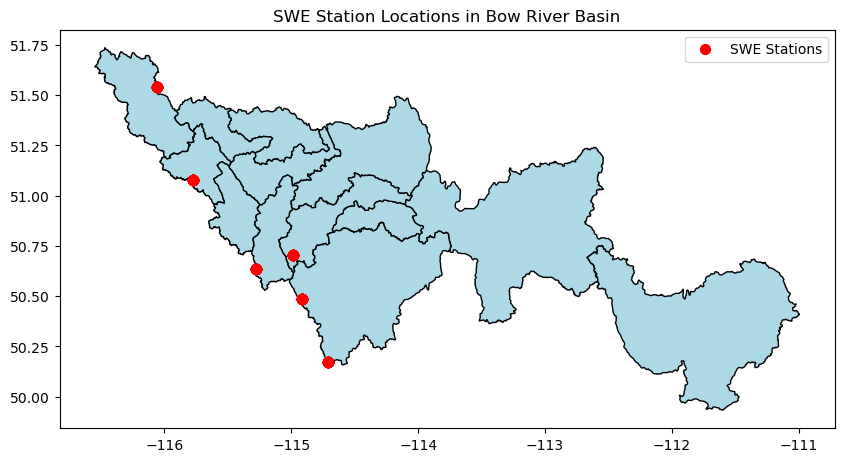

In [16]:
# plot station locations on bow river basin map
shapefile_path = config['shapefile']
bow_shapefile = gpd.read_file(shapefile_path)
bow_shapefile = bow_shapefile.to_crs(epsg=4326)

# convert to GeoDataFrame
gdf_bow_swe_data = gpd.GeoDataFrame(
    combined_bow,
    geometry=gpd.points_from_xy(combined_bow['lon'], combined_bow['lat']),
    crs='EPSG:4326'  # Assuming the coordinates are in WGS84
)

# plot
fig, ax = plt.subplots(figsize=(10, 10))
bow_shapefile.plot(ax=ax, color='lightblue', edgecolor='black')
gdf_bow_swe_data.plot(ax=ax, color='red', markersize=50
                        , label='SWE Stations')
ax.set_title('SWE Station Locations in Bow River Basin')
ax.legend()
plt.show()

# Calculate SWEI

In [66]:
# weekly SWEI calculation functions

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id","station_name"]]
        .drop_duplicates(subset=["station_id", "station_name"])
        .set_index("station_id")
    )


def daily_to_weekly_swe(
    df: pd.DataFrame,
    week_freq: str = "W-SUN",
    weekly_agg: str = "sum"
) -> pd.DataFrame:
    """
    Daily SWE -> weekly SWE.

    Parameters
    ----------
    week_freq : str
        Weekly resampling frequency, e.g. 'W-SUN', 'W-MON'
    weekly_agg : str
        Aggregation within week: 'last', 'mean', or 'max'

    Returns
    -------
    DataFrame with columns:
        station_id, time, SWE_weekly, Seasonal_Year, season_week
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    if weekly_agg == "last":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .last()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "sum":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .sum()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "max":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .max()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    else:
        raise ValueError("weekly_agg must be one of: 'last', 'mean', 'max'")

    # Recompute Seasonal_Year using Oct-May style start year
    # Oct 2025 - May 2026 => Seasonal_Year = 2025
    weekly["Seasonal_Year"] = np.where(
        weekly["time"].dt.month >= 10,
        weekly["time"].dt.year,
        weekly["time"].dt.year - 1
    )

    # Define season start = Oct 1 of Seasonal_Year
    season_start = pd.to_datetime(weekly["Seasonal_Year"].astype(str) + "-10-01")

    # season_week = week number within season
    weekly["season_week"] = ((weekly["time"] - season_start).dt.days // 7) + 1

    # Optional: keep only nov-May season weeks
    weekly = weekly[
        weekly["time"].dt.month.isin([ 10, 11, 12, 1, 2, 3, 4, 5])
    ].copy()

    return weekly


def rolling_integrated_swe_by_season_weekly(
    weekly_df: pd.DataFrame,
    window_weeks: int
) -> pd.DataFrame:
    """
    Compute rolling k-week integrated SWE within each Seasonal_Year.

    - Rolling windows do NOT cross Seasonal_Year boundaries.
    - First (k-1) weeks of each season are dropped.
    """
    out = weekly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_weeks}wk"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_weekly"]
        .rolling(window=window_weeks, min_periods=window_weeks)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_weeks}wk"])


def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid_weekly(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute weekly SWEI for ONE station_id using season-week standardization.

    Each week is standardized against the historical distribution of
    the same season_week for that station.
    """
    out = df.copy()

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for wk in sorted(out["season_week"].dropna().unique()):
        idx = out["season_week"] == wk
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out


def compute_weekly_swei(
    df: pd.DataFrame,
    window_weeks: int = 4,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    End-to-end weekly SWEI calculation with metadata preservation.

    Steps:
    1. Daily -> weekly SWE
    2. Rolling k-week integrated SWE within season
    3. Compute SWEI per Grid_id using season-week climatology
    4. Reattach static metadata
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily -> weekly SWE
    weekly = daily_to_weekly_swe(
        df,
        week_freq=week_freq,
        weekly_agg=weekly_agg
    )

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season_weekly(weekly, window_weeks)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid_weekly(
                g,
                swe_col=f"SWE_{window_weeks}wk"
            )
        )
        .reset_index(drop=True)
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei

1. Bow River Basin

In [67]:
Bow_weekly_swei = compute_weekly_swei(
    df=bow_swe_table,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SUN",   # weekly ending Saturday
    weekly_agg="last"    # recommended for SWE
)

display(Bow_weekly_swei.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
0,05BB803,1984-03-18,492.0,1983,25,492.0,0.378405,-0.309673,SUNSHINE VILLAGE
1,05BB803,1984-03-25,526.0,1983,26,526.0,0.451362,-0.122221,SUNSHINE VILLAGE
2,05BB803,1984-04-01,542.0,1983,27,542.0,0.448875,-0.128504,SUNSHINE VILLAGE
3,05BB803,1984-04-08,555.0,1983,28,555.0,0.437687,-0.156836,SUNSHINE VILLAGE
4,05BB803,1984-04-15,565.0,1983,29,565.0,0.387836,-0.284962,SUNSHINE VILLAGE


In [68]:
seasonal_year_summary = (
    Bow_weekly_swei
    .groupby('season_week')['SWEI']
    .agg(median='median', min='min', max='max')
    .reset_index()
)

display(seasonal_year_summary)

,season_week,median,min,max
0,1,0.000000e+00,-2.109874,2.109874
1,2,0.000000e+00,-2.167820,2.167820
2,3,0.000000e+00,-2.188546,2.188546
3,4,0.000000e+00,-2.178338,2.178338
4,5,0.000000e+00,-2.198461,2.198461
5,6,0.000000e+00,-2.208099,2.208099
6,7,0.000000e+00,-2.208099,2.208099
7,8,0.000000e+00,-2.208099,2.208099
8,9,0.000000e+00,-2.208099,2.208099
9,10,0.000000e+00,-2.198461,2.198461


In [69]:
season_2025_weekly = Bow_weekly_swei[Bow_weekly_swei['Seasonal_Year'] == 2005].copy()
display(season_2025_weekly)

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
631,05BB803,2005-10-02,15.060072,2005,1,15.060072,NaN,NaN,SUNSHINE VILLAGE
632,05BB803,2005-10-09,28.071207,2005,2,28.071207,0.771739,0.744586,SUNSHINE VILLAGE
633,05BB803,2005-10-16,41.082342,2005,3,41.082342,0.707641,0.546507,SUNSHINE VILLAGE
634,05BB803,2005-10-23,81.498470,2005,4,81.498470,0.877155,1.160883,SUNSHINE VILLAGE
635,05BB803,2005-10-30,88.838307,2005,5,88.838307,0.769397,0.736861,SUNSHINE VILLAGE
...,...,...,...,...,...,...,...,...,...
7168,05CA805,2006-04-30,233.454587,2005,31,233.454587,0.244376,-0.692294,SKOKI MOUNTAIN
7169,05CA805,2006-05-07,220.464130,2005,32,220.464130,0.311422,-0.491823,SKOKI MOUNTAIN
7170,05CA805,2006-05-14,167.473672,2005,33,167.473672,0.320044,-0.467575,SKOKI MOUNTAIN
7171,05CA805,2006-05-21,4.483215,2005,34,4.483215,0.153931,-1.019717,SKOKI MOUNTAIN


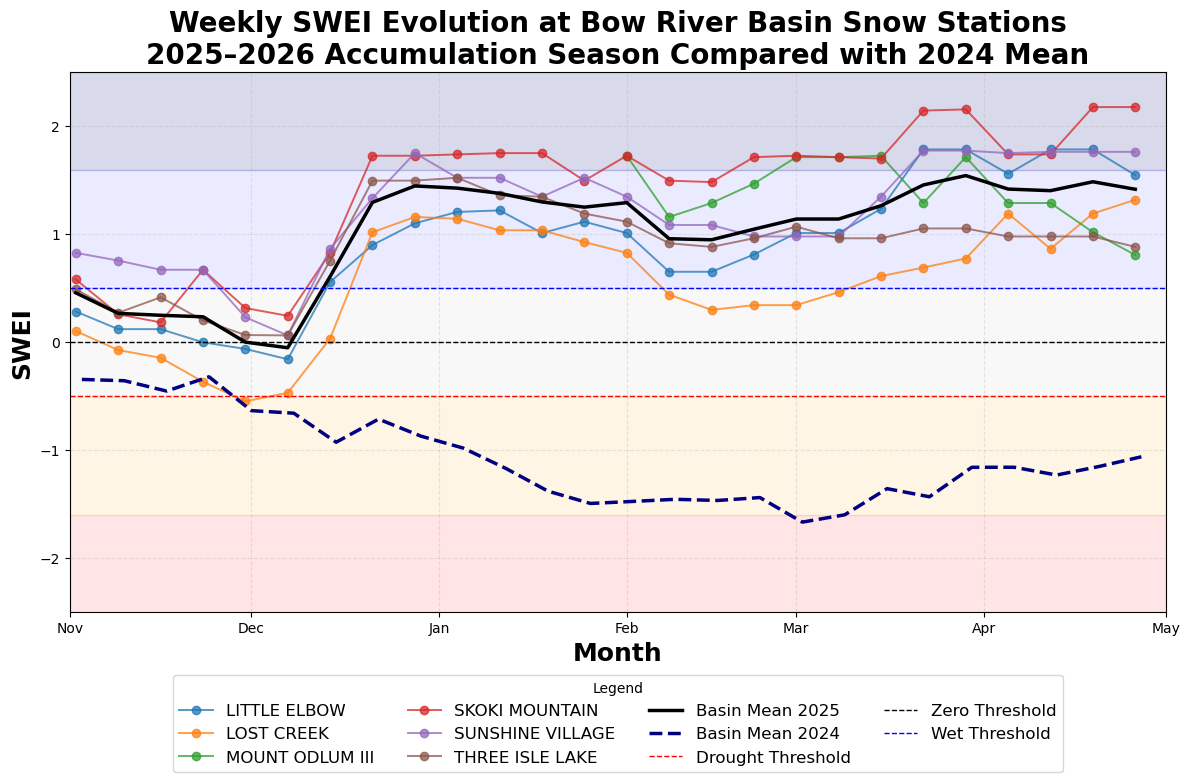

In [78]:
# --- select seasons ---
season_2025_weekly = Bow_weekly_swei[Bow_weekly_swei['Seasonal_Year'] == 2025].copy()
season_2024_weekly = Bow_weekly_swei[Bow_weekly_swei['Seasonal_Year'] == 2024].copy()

# remove October and May
season_2025_weekly = season_2025_weekly[season_2025_weekly['time'].dt.month != 10].copy()
season_2024_weekly = season_2024_weekly[season_2024_weekly['time'].dt.month != 10].copy()
season_2025_weekly = season_2025_weekly[season_2025_weekly['time'].dt.month != 5].copy()
season_2024_weekly = season_2024_weekly[season_2024_weekly['time'].dt.month != 5].copy()

# shift 2024 season to overlay with 2025 season
season_2024_weekly['plot_time'] = season_2024_weekly['time'] + pd.DateOffset(years=1)
season_2025_weekly['plot_time'] = season_2025_weekly['time']

fig, ax = plt.subplots(figsize=(12, 8))

# --- 2025 station lines ---
for station_name, group in season_2025_weekly.groupby('station_name'):
    group = group.sort_values('plot_time')
    ax.plot(
        group['plot_time'], group['SWEI'],
        marker='o', linewidth=1.4, alpha=0.75,
        label=station_name
    )

# --- basin mean 2025 ---
basin_mean_2025 = (
    season_2025_weekly
    .groupby('plot_time')['SWEI']
    .mean()
    .sort_index()
)

ax.plot(
    basin_mean_2025.index, basin_mean_2025.values,
    color='black', linewidth=2.5, linestyle='-',
    label='Basin Mean 2025'
)

# --- basin mean 2024 shifted ---
basin_mean_2024 = (
    season_2024_weekly
    .groupby('plot_time')['SWEI']
    .mean()
    .sort_index()
)

ax.plot(
    basin_mean_2024.index, basin_mean_2024.values,
    color='navy', linewidth=2.5, linestyle='--',
    label='Basin Mean 2024'
)

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.15)

# --- threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')

# --- labels ---
ax.set_title(
    'Weekly SWEI Evolution at Bow River Basin Snow Stations\n'
    '2025–2026 Accumulation Season Compared with 2024 Mean',
    fontsize=20, fontweight='bold'
)

ax.set_xlabel('Month', fontsize=18,fontweight='bold')
ax.set_ylabel('SWEI', fontsize=18,fontweight='bold')

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5, 2.5)

# optional: set x-axis from Nov to May
ax.set_xlim(pd.Timestamp('2025-11-01'), pd.Timestamp('2026-05-01'))

# --- grid and legend ---
ax.grid(True, linestyle='--', alpha=0.3)

ax.legend(
        title='Legend',
        bbox_to_anchor=(0.5, -0.10),
        loc='upper center',
        ncol=4,
        fontsize=12
)

plt.tight_layout()

save_path = config['output_plots'] / 'season_2025_weekly_swei_with_2024_mean.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()

In [144]:
Oldman_weekly_swei = compute_weekly_swei(
    df=oldman_swe_table,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SAT",   # weekly ending Saturday
    weekly_agg="last"    # recommended for SWE
)

display(Oldman_weekly_swei.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
0,05AA809,1984-04-07,440.0,1983,28,440.0,0.167689,-0.963337,GARDINER H.W.
1,05AA809,1984-04-14,458.0,1983,29,458.0,0.218814,-0.776205,GARDINER H.W.
2,05AA809,1984-04-21,456.0,1983,30,456.0,0.224554,-0.756903,GARDINER H.W.
3,05AA809,1984-04-28,460.0,1983,31,460.0,0.257543,-0.650938,GARDINER H.W.
4,05AA809,1984-05-05,492.0,1983,32,492.0,0.419181,-0.203989,GARDINER H.W.


In [147]:
print("Unique Oldman station_name_gapfilled values:")
print(Oldman_weekly_swei['station_name'].unique())

Unique Oldman station_name_gapfilled values:
['GARDINER H.W.' 'SOUTH RACE HORSE CREEK' 'AKAMINA']


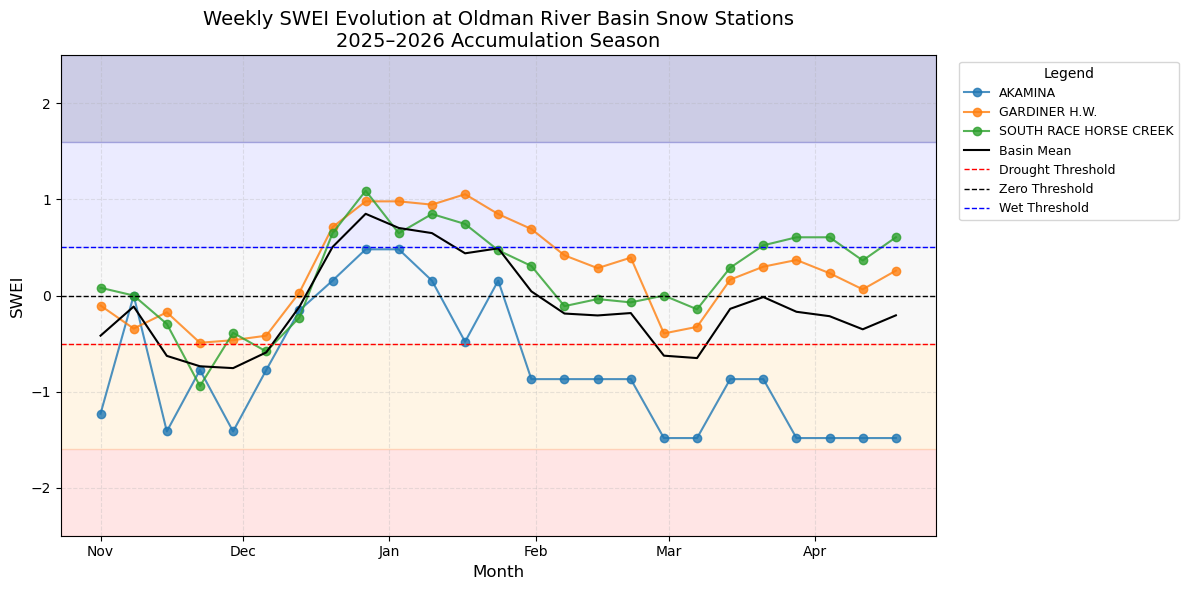

In [151]:
# plot for season 2025
season_2025_weekly = Oldman_weekly_swei[Oldman_weekly_swei['Seasonal_Year'] == 2025].copy()

# remove October for the report
season_2025_weekly = season_2025_weekly[season_2025_weekly['time'].dt.month != 10].copy()

fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name, group in season_2025_weekly.groupby('station_name'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name)

# --- optional basin mean ---
basin_mean = season_2025_weekly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')
# --- labels ---
ax.set_title('Weekly SWEI Evolution at Oldman River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'season_2025_weekly_swei_oldman.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()

2. Monthly SWEI

In [154]:
# monthly SWEI calculation functions 

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id","station_name"]]
        .drop_duplicates(subset=["station_id", "station_name"])
        .set_index("station_id")
    )


def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute SWEI for ONE Grid_id using calendar-month standardization.
    """
    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue  # Near-normal (NN)

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3
) -> pd.DataFrame:
    """
    End‑to‑end SWEI calculation with metadata preservation.
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily → monthly SWE
    monthly = daily_to_monthly_swe(df)

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei


In [155]:
# Bow River Basin
bow_swei_1mo = compute_swei(bow_swe_table, window_months=1)
display(bow_swei_1mo)

# Oldman River Basin
oldman_swei_1mo = compute_swei(oldman_swe_table, window_months=1)
display(oldman_swei_1mo)

,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI,station_name
0,05BB803,1984-03-01,8730.000000,1983,8730.000000,3,0.013619,-2.208099,SUNSHINE VILLAGE
1,05BB803,1984-04-01,16847.000000,1983,16847.000000,4,0.500000,0.000000,SUNSHINE VILLAGE
2,05BB803,1984-05-01,17495.000000,1983,17495.000000,5,0.512463,0.031244,SUNSHINE VILLAGE
3,05BB803,1985-01-01,9966.000000,1984,9966.000000,1,0.487537,-0.031244,SUNSHINE VILLAGE
4,05BB803,1985-02-01,9010.000000,1984,9010.000000,2,0.163509,-0.980136,SUNSHINE VILLAGE
...,...,...,...,...,...,...,...,...,...
1873,05CA805,2025-12-01,6134.027805,2025,6134.027805,12,0.906611,1.320169,SKOKI MOUNTAIN
1874,05CA805,2026-01-01,9611.779704,2025,9611.779704,1,0.960123,1.752112,SKOKI MOUNTAIN
1875,05CA805,2026-02-01,9869.654761,2025,9869.654761,2,0.959077,1.740070,SKOKI MOUNTAIN
1876,05CA805,2026-03-01,13963.135833,2025,13963.135833,3,0.959077,1.740070,SKOKI MOUNTAIN


,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI,station_name
0,05AA809,1984-04-01,12167.000000,1983,12167.000000,4,0.188435,-0.883679,GARDINER H.W.
1,05AA809,1984-05-01,16157.000000,1983,16157.000000,5,0.618048,0.300359,GARDINER H.W.
2,05AA809,1984-10-01,235.000000,1984,235.000000,10,0.434418,-0.165138,GARDINER H.W.
3,05AA809,1984-11-01,4734.000000,1984,4734.000000,11,0.936191,1.523566,GARDINER H.W.
4,05AA809,1984-12-01,8898.000000,1984,8898.000000,12,0.836491,0.980136,GARDINER H.W.
...,...,...,...,...,...,...,...,...,...
648,05AD803,2025-12-01,2990.967581,2025,2990.967581,12,0.561576,0.154967,AKAMINA
649,05AD803,2026-01-01,5600.305471,2025,5600.305471,1,0.561576,0.154967,AKAMINA
650,05AD803,2026-02-01,4523.163032,2025,4523.163032,2,0.192118,-0.870117,AKAMINA
651,05AD803,2026-03-01,6337.941570,2025,6337.941570,3,0.068966,-1.483540,AKAMINA


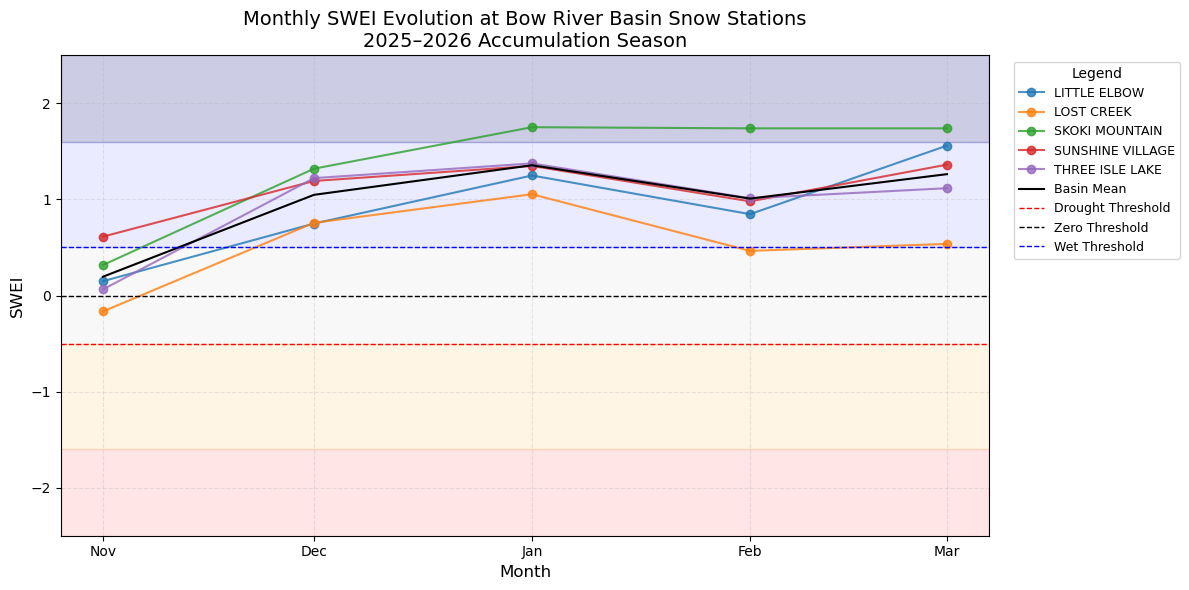

In [163]:
# plot for monthly SWEI season 2025
filtered = bow_swei_1mo[
    (bow_swei_1mo['Seasonal_Year'] == 2025) &
    (bow_swei_1mo['station_name'] != 'MOUNT ODLUM III')
].copy()

basin_mean = (
    filtered.groupby('time')['SWEI']
    .mean()
    .reset_index()
)



# remove  October for the report
season_2025_Monthly = filtered[~filtered['time'].dt.month.isin([10,4])].copy()



fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name_gapfilled, group in season_2025_Monthly.groupby('station_name'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name_gapfilled)
    

# --- optional basin mean ---
basin_mean = season_2025_Monthly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')

# --- labels ---
ax.set_title('Monthly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'bow_season_2025_monthly_swei.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()